<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W3_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

In [83]:
from torch.utils.data import Dataset, DataLoader, random_split

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
df = pd.read_csv("/content/drive/MyDrive/PRISM/processed/TCS.NS_processed.csv")

#Basic Feature Preprocessing

In [86]:
df.head()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
0,2019-04-02,1709.451782,1714.960003,1674.675708,1674.757900,3719663,0.023454,0.023183,1654.418750,1653.493787,1651.925543,0.010694,0.774869,2817120.55,0.003775,0.872854,0.000000
1,2019-04-03,1709.451782,1717.919746,1692.022699,1714.137874,2939886,0.000000,0.000000,1670.310425,1658.138818,1655.374359,0.010672,-0.209636,2756687.45,-0.005912,0.846227,-0.031164
2,2019-04-04,1656.177979,1709.780720,1650.340886,1708.506381,4397518,-0.031164,-0.031660,1677.972656,1657.456470,1656.459564,0.012978,0.495812,2854082.25,-0.003946,0.927317,0.016778
3,2019-04-05,1683.966064,1688.980929,1659.713271,1667.811217,3152103,0.016778,0.016639,1685.865063,1660.190063,1658.461456,0.013428,-0.283209,2879935.05,0.005859,0.938799,0.010960
4,2019-04-08,1702.422729,1705.916776,1671.140697,1692.762719,2194294,0.010960,0.010901,1692.294067,1665.542102,1660.823022,0.013548,-0.303863,2862655.55,-0.005267,0.903789,0.010021


In [87]:
df.shape

(1417, 17)

In [88]:
df["Date"]=pd.to_datetime(df["Date"])

In [133]:
df.info() #dtype of date is object by default iss liye upar wali line mai convert kiya

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1417 non-null   object 
 1   Close          1417 non-null   float64
 2   High           1417 non-null   float64
 3   Low            1417 non-null   float64
 4   Open           1417 non-null   float64
 5   Volume         1417 non-null   int64  
 6   return         1417 non-null   float64
 7   log_return     1417 non-null   float64
 8   MA5            1417 non-null   float64
 9   MA10           1417 non-null   float64
 10  MA20           1417 non-null   float64
 11  Volatility     1417 non-null   float64
 12  Volume_Change  1417 non-null   float64
 13  Volume_MA20    1417 non-null   float64
 14  market_return  1417 non-null   float64
 15  beta           1417 non-null   float64
 16  target         1417 non-null   float64
dtypes: float64(15), int64(1), object(1)
memory usage: 18

In [134]:
features=['Close','Volume','return','log_return','beta','MA5','MA10','MA20','Volume_Change','Volatility','Volume_MA20']
X = df[features]
y = df["target"]

In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()         #mean is near to 0 and variance is approx 1

In [136]:
X_scaled = scaler.fit_transform(X) #yeh np array return karta hai kyuki upar pehle se hii X and y ek array ki tarah hai

In [137]:
print(X_scaled.shape) #transform har value ko (x-mean)/std se replace

(1417, 11)


In [138]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

In [139]:
X_scaled.head()

,Close,Volume,return,log_return,beta,MA5,MA10,MA20,Volume_Change,Volatility,Volume_MA20
0,-1.391396,-0.624923,-0.338960,-0.333386,-0.703074,-1.419602,-1.390164,-1.447674,-0.313734,-0.866034,-0.741713
1,-1.442432,-0.581355,-0.668002,-0.667265,-0.399580,-1.418059,-1.394825,-1.439176,0.086898,-0.799632,-1.012761
2,-1.438237,-0.622183,0.031439,0.040193,-0.331021,-1.417077,-1.398782,-1.433670,-0.298481,-0.863224,-1.079204
3,-1.437539,-0.604599,-0.013319,-0.004823,-0.319541,-1.416692,-1.409299,-1.427067,-0.080059,-0.877364,-1.092471
4,-1.438936,-0.617892,-0.040104,-0.031779,-0.322283,-1.431279,-1.422928,-1.424517,-0.234378,-0.991822,-1.112020


#Sequences Creation and then to Tensor

In [140]:
sequence_length = 30
X_sequences=[]
y_sequences=[]

In [141]:
#Purane sequence_length din ka data input banata hai aur uske agle din ka target banata hai.
for i in range(len(X_scaled) - sequence_length):
    X_sequences.append(
        X_scaled.iloc[i:i+sequence_length].values
    )

    y_sequences.append(
        y.iloc[i+sequence_length]
    )
    #abb yeh ek type of list return karega like 2D list

In [142]:
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print(X_sequences.shape)
print(y_sequences.shape)

(1387, 30, 11)
(1387,)


In [143]:
#lekin usko tensor mai convert karna padega
X_tensor = torch.tensor(
    X_sequences,
    dtype=torch.float32
)
y_tensor = torch.tensor(
    y_sequences,
    dtype=torch.float32
)

In [144]:
print(X_tensor.shape) #1387 traing example ,unme se har example mai 30 days and har day mai 11 features
print(y_tensor.shape)

torch.Size([1387, 30, 11])
torch.Size([1387])


In [145]:
print(X_tensor.dtype)
print(y_tensor.dtype)

torch.float32
torch.float32


In [146]:
print(X_tensor[0].shape)

torch.Size([30, 11])


#Creating Custom Dataset and Dataloader

In [103]:
#Ye class X aur y ko PyTorch-compatible dataset me convert karta hai, taaki DataLoader unhe batches bana kar model ko de sake
class StockDataset(Dataset):
    def __init__(self, X, y):   #Input features aur target values ko dataset ke andar save kar do
        self.X = X
        self.y = y
    def __len__(self):          #Dataset me total kitne training examples hain, wo bata do
        return len(self.X)
    def __getitem__(self, idx):  #idx number wale sample ka X aur y de do.
        return self.X[idx], self.y[idx]

In [104]:
dataset = StockDataset(
    X_tensor,
    y_tensor
)

In [105]:
len(dataset)

1387

In [106]:
x,y = dataset[0]
print(x.shape) #past 30 training eg and har example ke 11 features
print(y)       #yeh uske agle diin ka target return karega

torch.Size([30, 11])
tensor(-0.0160)


In [107]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [108]:
#checking a batch
for X_batch, y_batch in loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 30, 11])
torch.Size([32])


In [109]:
train_size = int(
    0.8 * len(dataset)
)
val_size = len(dataset) - train_size

In [110]:
#Subset original dataset me se selected indices (yahan pe training eg) ko lekar ek naya dataset banata hai, taaki model sirf training data par train ho..same goes with val_dataset
train_dataset = torch.utils.data.Subset(
    dataset,
    range(train_size)
)
val_dataset = torch.utils.data.Subset(
    dataset,
    range(train_size,len(dataset))
)

In [111]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [112]:
print(len(train_dataset))
print(len(val_dataset))

1109
278


In [113]:
#Model yahan wt update karta hai
for X_batch,y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 30, 11])
torch.Size([32])


#Processing all Stocks

In [114]:
processed_path="/content/drive/MyDrive/PRISM/processed"
files=[
    f for f in os.listdir(processed_path)
    if f.endswith("_processed.csv")
]
files=[f for f in files
       if f!="^NSEI_processed.csv"]          #skipping nsei files kyuki usme rows bakchodi kar rahi hai

In [115]:
#Iss pure code ka kaam hai 500 stock files ko ek hi training dataset me convert karna
all_X = []
all_y = []
sequence_length = 30

features=['Close','Volume','return','log_return','beta','MA5','MA10','MA20','Volume_Change','Volatility','Volume_MA20']
for file in files:
    df = pd.read_csv(
        os.path.join(processed_path, file)
    )

    X = df[features].values
    y = df["target"].values

    X_seq = []
    y_seq = []

    for i in range(len(df) - sequence_length):
        X_seq.append(
            X[i:i+sequence_length]
        )
        y_seq.append(
            y[i+sequence_length]
        )
    print(file, len(X_seq))

    all_X.extend(X_seq)
    all_y.extend(y_seq)

all_X = np.array(all_X)
all_y = np.array(all_y)


AARTIDRUGS.NS_processed.csv 1387
3MINDIA.NS_processed.csv 1387
ABCAPITAL.NS_processed.csv 1387
ABBOTINDIA.NS_processed.csv 1387
ABFRL.NS_processed.csv 1387
ABSLAMC.NS_processed.csv 705
ADANIENT.NS_processed.csv 1387
ACC.NS_processed.csv 1387
ADANIPORTS.NS_processed.csv 1387
ADANIGREEN.NS_processed.csv 1387
ADANITRANS.NS_processed.csv 0
ABB.NS_processed.csv 1387
TCS_processed.csv 1387
AAVAS.NS_processed.csv 1387
ADVENZYMES.NS_processed.csv 1387
AEGISCHEM.NS_processed.csv 0
AFFLE.NS_processed.csv 1240
AIAENG.NS_processed.csv 1387
AJANTPHARM.NS_processed.csv 1387
ALKEM.NS_processed.csv 1387
ALKYLAMINE.NS_processed.csv 1387
ALLCARGO.NS_processed.csv 1387
ALOKINDS.NS_processed.csv 1375
AMARAJABAT.NS_processed.csv 0
AMBER.NS_processed.csv 1387
AMBUJACEM.NS_processed.csv 1387
ANGELONE.NS_processed.csv 957
ANURAS.NS_processed.csv 840
APLAPOLLO.NS_processed.csv 1387
APOLLOHOSP.NS_processed.csv 1387
ALEMBICPHARM.NS_processed.csv 0
APOLLOTYRE.NS_processed.csv 1387
APTUS.NS_processed.csv 738
ASAHI

neeche saara same code hai just upar se copy kiya hai for 500 stock files

In [116]:
print(all_X.shape)
print(all_y.shape)

(613151, 30, 11)
(613151,)


In [117]:
print(len(files))
print(len(all_X))

501
613151


In [118]:
X_tensor=torch.tensor(
    all_X,
    dtype=torch.float32
)
y_tensor=torch.tensor(
    all_y,
    dtype=torch.float32
)

In [119]:
print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([613151, 30, 11])
torch.Size([613151])


In [120]:
class StockDataset(Dataset):
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

In [121]:
dataset=StockDataset(
    X_tensor,
    y_tensor
)
print(len(dataset))

613151


In [122]:
split = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(
    dataset,
    range(split)
)

val_dataset = torch.utils.data.Subset(
    dataset,
    range(split, len(dataset))
)

In [123]:
train_loader=DataLoader(
train_dataset,
batch_size=32,
shuffle=False
)

val_loader=DataLoader(
val_dataset,
batch_size=32,
shuffle=False
)

In [124]:
for X,y in train_loader:
    print(X.shape)
    print(y.shape)
    break

torch.Size([32, 30, 11])
torch.Size([32])


In [125]:
print(len(dataset))
print(X_tensor.shape)
print(y_tensor.shape)

613151
torch.Size([613151, 30, 11])
torch.Size([613151])


In [126]:
sample_X,sample_y=dataset[0]

print(sample_X.shape)

print(sample_y)

torch.Size([30, 11])
tensor(-0.0154)


In [127]:
for X,y in train_loader:
    print(X.shape)
    print(y.shape)
    break

torch.Size([32, 30, 11])
torch.Size([32])


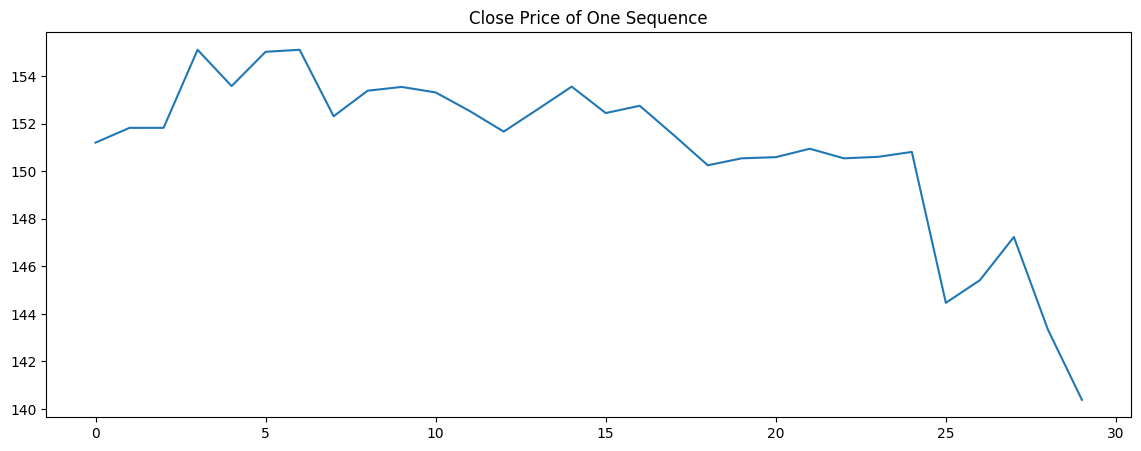

In [128]:
plt.figure(figsize=(14,5))

plt.plot(
sample_X[:,0]
)
plt.title(
"Close Price of One Sequence"
)
plt.show()

In [129]:
torch.save(
dataset,
"/content/drive/MyDrive/PRISM/train_dataset.pt"
)